In [20]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import  DataLoader,Subset
import torch.optim as optim
from torchsummary import summary
import torch.nn.functional as F
from torchvision import transforms,datasets
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

device= torch.device ('cuda'if  torch.cuda.is_available()  else 'cpu')


In [7]:
transform=transforms.Compose([transforms.Resize((64,64)),
                              transforms.ToTensor(),
                              transforms.Normalize((0.5),
                                                   (0.5))])
train_dataset=datasets.MNIST(root='data',
                             train=True,
                             download=True,
                             transform=transform)

subset_indices=list(range(9000))
subset_data_set=Subset(train_dataset,subset_indices)

data_loader = DataLoader(subset_data_set,batch_size=200,shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 499kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.23MB/s]


In [28]:
class UnetAutoEncoder(nn.Module):
  def __init__(self,input_features):
    super().__init__()
    #Encoder
    self.encoder_=nn.Sequential(
        #Encoder 1
        nn.Conv2d(input_features,64,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(64,64,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 2
        nn.MaxPool2d(2),
        nn.Conv2d(64,128,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(128,128,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 3
        nn.MaxPool2d(2),
        nn.Conv2d(128,256,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(256,256,kernel_size=3,padding=1),
        nn.ReLU(),

        #Encoder 4
        nn.MaxPool2d(2),
        nn.Conv2d(256,512,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(512,512,kernel_size=3,padding=1),
        nn.ReLU()
    )

    #Bottleneck
    self.bottleneck_=nn.Sequential(
        nn.MaxPool2d(2),
        nn.Conv2d(512,1024,kernel_size=3,padding=1),
        nn.ReLU(),
        nn.Conv2d(1024,1024,kernel_size=3,padding=1),
        nn.ReLU()
    )
    #Decoder
    self.decoder_= nn.Sequential(#Decoder 1
            nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2),
            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(512,512,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 2
            nn.ConvTranspose2d(512,256,kernel_size=2,stride=2),
            nn.Conv2d(256,256,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(256,256,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 3
            nn.ConvTranspose2d(256,128,kernel_size=2,stride=2),
            nn.Conv2d(128,128,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(128,128,kernel_size=3,padding=1),
            nn.ReLU(),

            #Decoder 4
            nn.ConvTranspose2d(128,64,kernel_size=2,stride=2),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.Conv2d(64,64,kernel_size=3,padding=1),
            nn.ReLU(),

            #output Layer
            nn.Conv2d(64,1,kernel_size=1)
            )

  def forward(self,x):
    x=self.encoder_(x)
    encoder=x.clone()
    x=self.bottleneck_(x)
    x=self.decoder_(x)
    return(x,encoder)

  # Encoder
  def encoder(self,x):
    x=self.encoder_(x)
    return(x)

  # Bottleneck
  def bottleneck(self,x):
    x=self.bottleneck_(x)
    # print('bottleneck')
    return(x)

  #Decoder
  def decoder (self,x):
    x=self.decoder_(x)
    return x


In [29]:
class SparseAutoEncoder(UnetAutoEncoder):
    def __init__(self,in_dim,s_lambda=1e-6,s_target=0.05,xavier_nprm_init=True):
        super().__init__(in_dim)
        self.sparsity_lambda=s_lambda
        self.sparsity_target=s_target
        self.xavier_nprm_init=xavier_nprm_init
        # if self.xavier_nprm_init:
        #     nn.init.xavier_uniform_(self.encoder_.weight)
        #     nn.init.xavier_uniform_(self.encoder_.bias,0)

    def sparsity_penalty(self,encoded):
        rho_hat=torch.mean(encoded,dim=(0,2,3))
        rho=self.sparsity_target
        epsilon= 1e-3
        rho_hat=torch.clamp(rho_hat,min=epsilon,max=1-epsilon)
        # print("rho_hat min:", rho_hat.min().item(), "max:", rho_hat.max().item())
        kl_divergence=rho*torch.log(rho/rho_hat)+(1-rho)*torch.log((1-rho)/(1-rho_hat))
        sparsity_penalty=torch.sum(kl_divergence)
        return self.sparsity_lambda*sparsity_penalty

    def loss_function(self,x_hat,x,encoded):
        mse=F.mse_loss(x_hat,x)
        sparsity_loss=self.sparsity_penalty(encoded)
        # print(f'MSE={mse}')
        # print(f'Sparsity={sparsity_loss}')
        return mse+sparsity_loss

In [10]:
#Train the model
def train_model(model,dataloader,epochs,optimizer):
    for epoch in range(epochs):
        total_loss=0
        for records,_ in dataloader:
            records=records.to(device)
            optimizer.zero_grad()
            decoded,encoded=model.forward(records)
            loss=model.loss_function(decoded,records,encoded)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss+=loss.item()
        print(f'Epoch: {epoch+1}/{epochs}- Train L: {float(total_loss/len(data_loader))}')
        if epoch%5==0:
          torch.save(model.state_dict(),'Unet_sparse_autoencoder.pkl')

In [11]:
model=SparseAutoEncoder(1)
model.to(device)
optimizer = optim.Adam(model.parameters(),lr=0.0005)
epochs=20

In [12]:
train_model(model,data_loader,epochs,optimizer)

Epoch: 1/20- Train L: 8.293553810649447
Epoch: 2/20- Train L: 0.264568273557557
Epoch: 3/20- Train L: 0.1995995044708252
Epoch: 4/20- Train L: 0.1498106100493007
Epoch: 5/20- Train L: 0.08327041367689768
Epoch: 6/20- Train L: 0.06509738084342745
Epoch: 7/20- Train L: 0.04445422622892592
Epoch: 8/20- Train L: 0.030153743508789275
Epoch: 9/20- Train L: 0.02391457615627183
Epoch: 10/20- Train L: 0.020319774539934263
Epoch: 11/20- Train L: 0.017665550464557277
Epoch: 12/20- Train L: 0.015058301202952862
Epoch: 13/20- Train L: 0.014258001558482647
Epoch: 14/20- Train L: 0.012413131900959544
Epoch: 15/20- Train L: 0.012244458517266644
Epoch: 16/20- Train L: 0.010365313808951114
Epoch: 17/20- Train L: 0.010838396122886075
Epoch: 18/20- Train L: 0.009721718438797527
Epoch: 19/20- Train L: 0.010035015911691718
Epoch: 20/20- Train L: 0.008505987893376086


In [13]:
torch.save(model.state_dict(),'Unet_sparse_autoencoder.pkl')

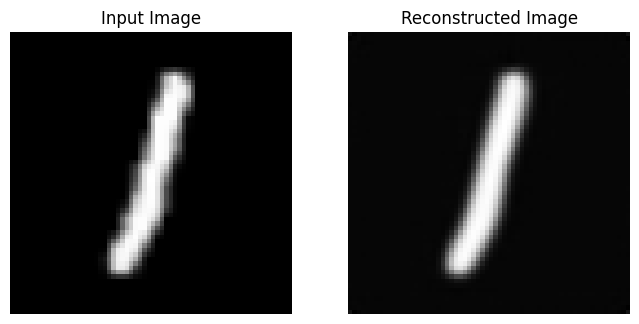

In [17]:
# Get one sample
data_loader1 = DataLoader(subset_data_set,batch_size=1,shuffle=True)
data_iter = iter(data_loader1)
img, label = next(data_iter)  # img shape: (1,1,64,64)

# Pass through model
model.eval()
with torch.no_grad():
  img=img.to(device)
  output, _ = model(img)

# Prepare for plotting
input_img = img.squeeze().cpu().numpy()
output_img = output.squeeze().cpu().numpy()

# De-normalize if needed (from [-1,1] back to [0,1])
input_img = (input_img * 0.5) + 0.5
output_img = (output_img * 0.5) + 0.5

# Plot side by side
plt.figure(figsize=(8,4))

# Input
plt.subplot(1,2,1)
plt.imshow(input_img, cmap='gray')
plt.title("Input Image")
plt.axis('off')

# Output
plt.subplot(1,2,2)
plt.imshow(output_img, cmap='gray')
plt.title("Reconstructed Image")
plt.axis('off')

plt.show()

## (a) (20 points) Plot the t-sne (use inbuilt function) on the embeddings obtained using the respective auto-encoders. Color the clusters using the respective ground-truth class labels.

In [32]:
model=SparseAutoEncoder(1)
model.load_state_dict(torch.load('Unet_sparse_autoencoder.pkl'))
model.to(device)

SparseAutoEncoder(
  (encoder_): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (16): ReLU()
    (17): Conv2d(512, 512, kernel_size=(3, 3), stri

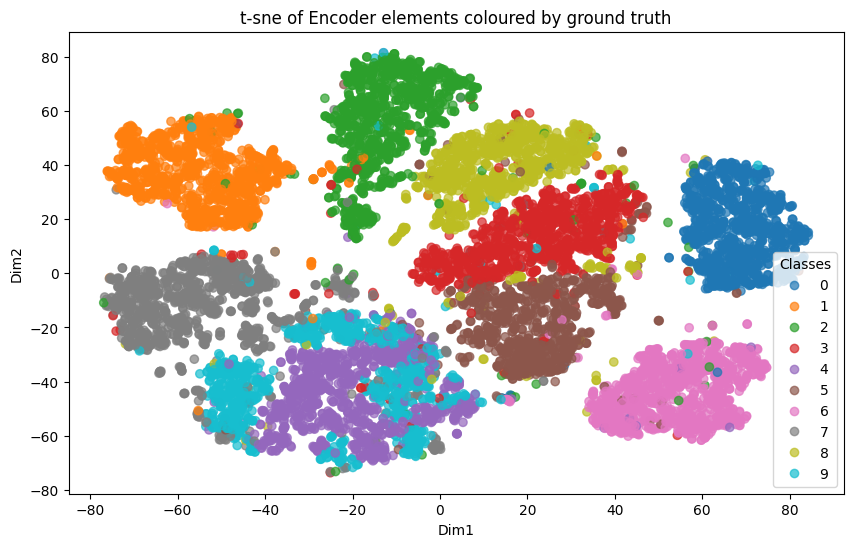

In [22]:
subset_indices=list(range(10000))
subset_data_set=Subset(train_dataset,subset_indices)
data_loader_eval = DataLoader(subset_data_set,batch_size=100,shuffle=True)
embeddings= []
labels=[]

model.eval()
with torch.no_grad():
    for data,label in data_loader_eval:
        data=data.to(device)

        # encoder Embeddings
        encoder_embeddings=model.encoder(data)

        #Flatening the sample for t-sne
        encoder_embeddings_flattened=encoder_embeddings.view(encoder_embeddings.size(0),-1)

        embeddings.append(encoder_embeddings_flattened)
        labels.append(label)

#concatinate the embeddings and labels
embeddings=torch.cat(embeddings,dim=0)
labels=torch.cat(labels,dim=0)

#Apply t-sne
tsne= TSNE(n_components=2,random_state=42)
embeddings_in_2d=tsne.fit_transform(embeddings.detach().cpu().numpy())

#Plot
plt.figure(figsize=(10,6))
scatter=plt.scatter(embeddings_in_2d[:,0],embeddings_in_2d[:,1],c=labels,cmap='tab10',alpha=0.7)
plt.legend(*scatter.legend_elements(),title='Classes')
plt.title('t-sne of Encoder elements coloured by ground truth')
plt.xlabel('Dim1')
plt.ylabel('Dim2')
plt.show()

![image.png](attachment:image.png)



In [23]:
subset_indices=list(range(100))
subset_data_set=Subset(train_dataset,subset_indices)
data_loader_q2 = DataLoader(subset_data_set,batch_size=2,shuffle=True)

In [24]:
def calculate_psnr(img1,img2,max_value=1):
    '''The images are tensors of same dimension with values [0,1]'''
    mse=torch.mean((img1-img2)**2)
    if mse==0:
        return float('inf')
    else:
        psnr_value=20*torch.log10(max_value/mse)
    return psnr_value
def l2norm(img1,img2):
    l2diff=torch.norm(img1-img2,p=2)
    return l2diff


--------------------------------> For the image Pair 1 <--------------------------------



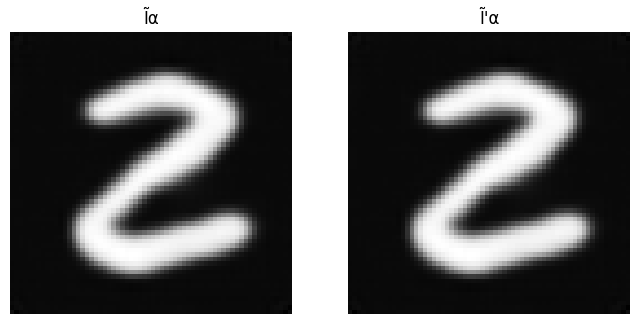

PSNR Value inf ----- L2 value 0.0


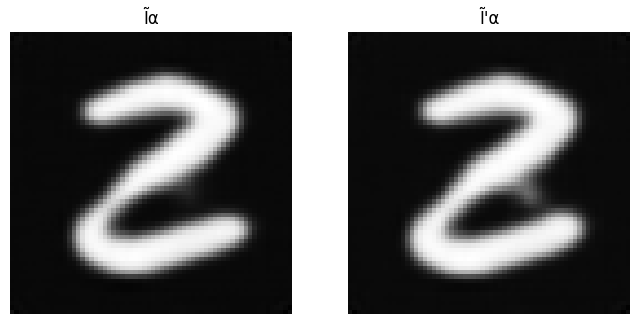

PSNR Value 44.669002532958984 ----- L2 value 4.891645431518555


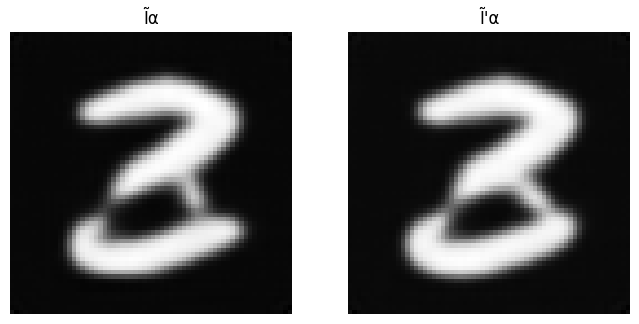

PSNR Value 38.32337951660156 ----- L2 value 7.048479080200195


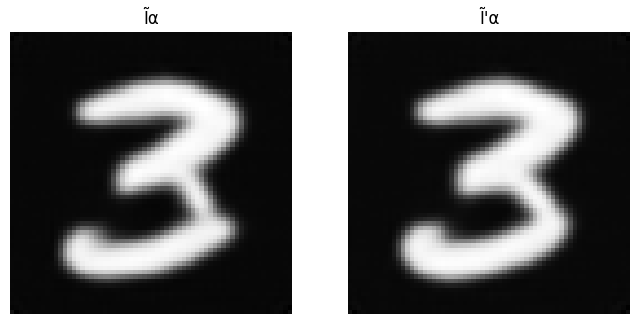

PSNR Value 40.55127716064453 ----- L2 value 6.200091361999512


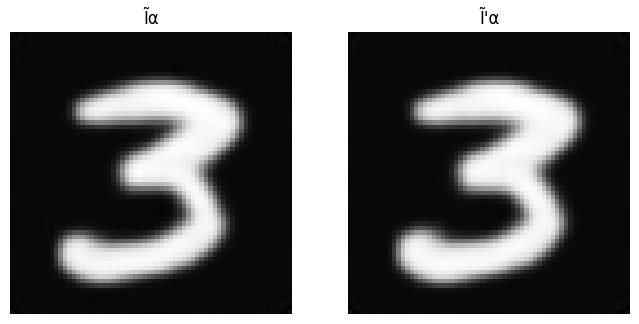

PSNR Value 48.736576080322266 ----- L2 value 3.8704864978790283


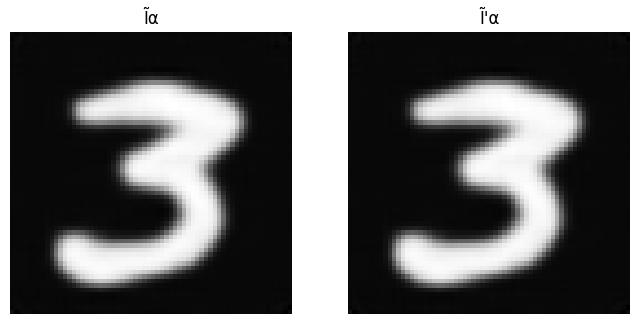

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 2 <--------------------------------



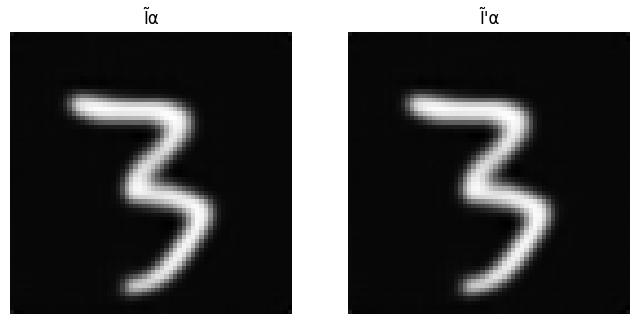

PSNR Value inf ----- L2 value 0.0


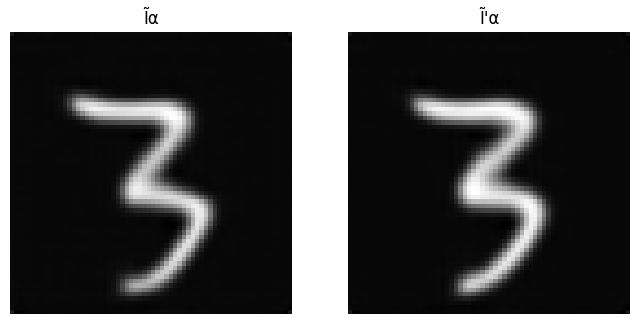

PSNR Value 37.94566345214844 ----- L2 value 7.203415870666504


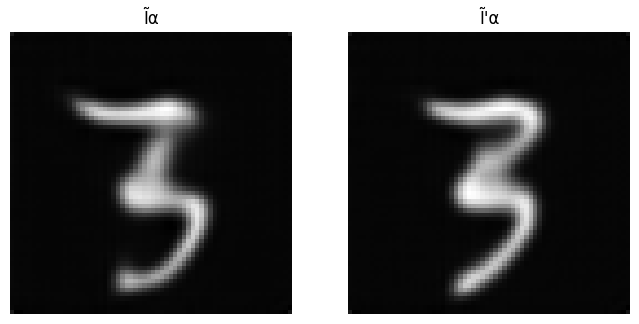

PSNR Value 28.773174285888672 ----- L2 value 12.213794708251953


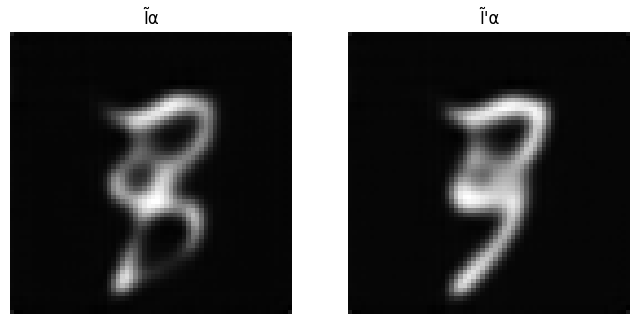

PSNR Value 28.689708709716797 ----- L2 value 12.27262020111084


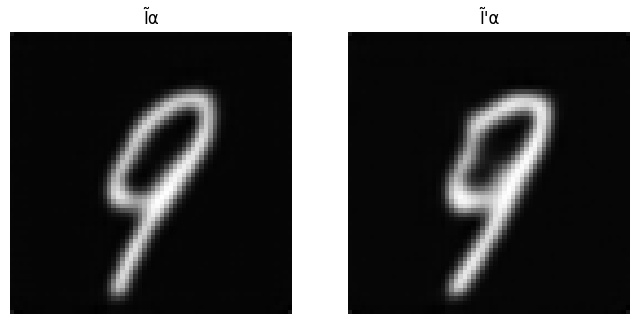

PSNR Value 33.779541015625 ----- L2 value 9.1556978225708


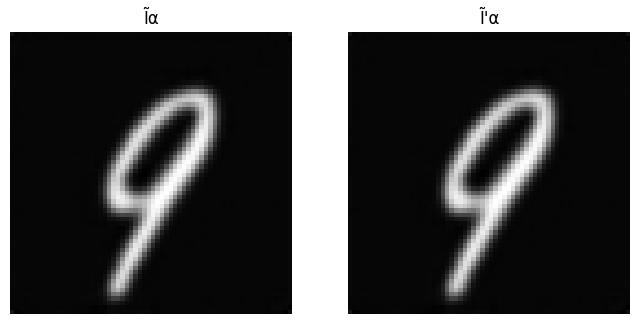

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 3 <--------------------------------



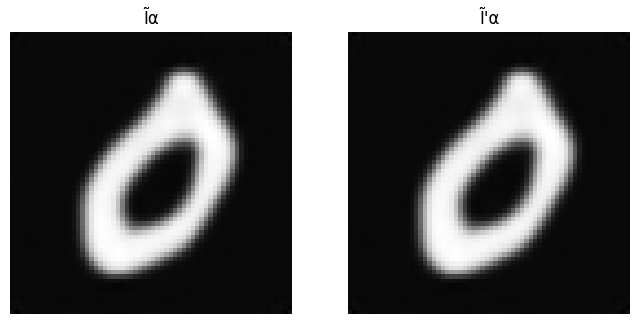

PSNR Value inf ----- L2 value 0.0


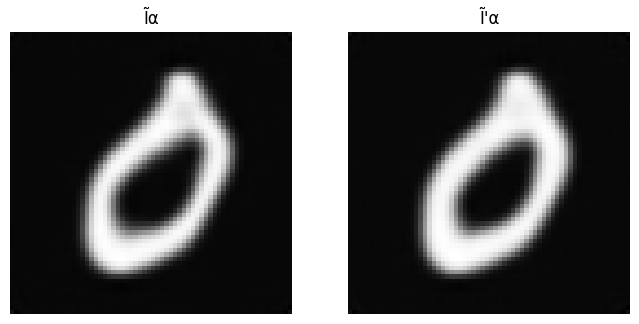

PSNR Value 43.066410064697266 ----- L2 value 5.364382266998291


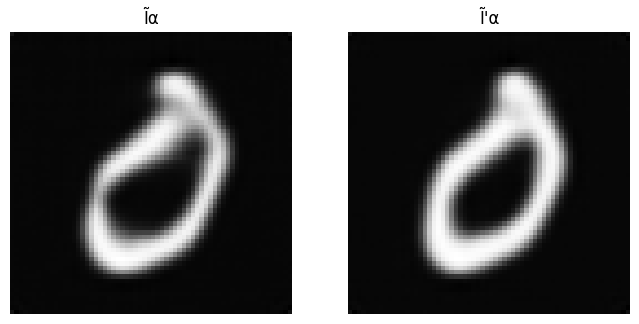

PSNR Value 32.837127685546875 ----- L2 value 9.666112899780273


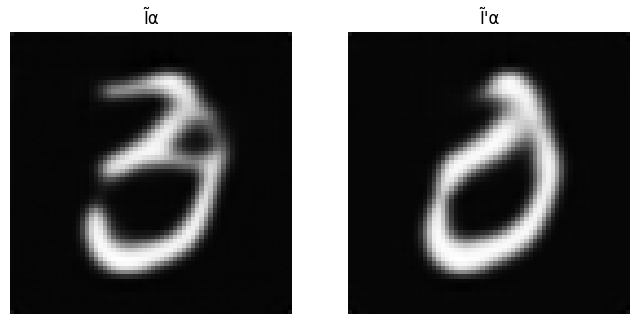

PSNR Value 26.859355926513672 ----- L2 value 13.636286735534668


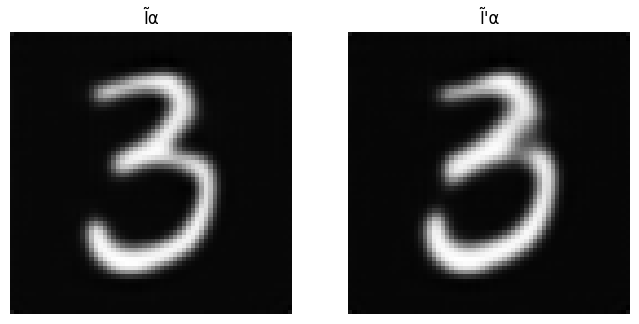

PSNR Value 32.69324493408203 ----- L2 value 9.746502876281738


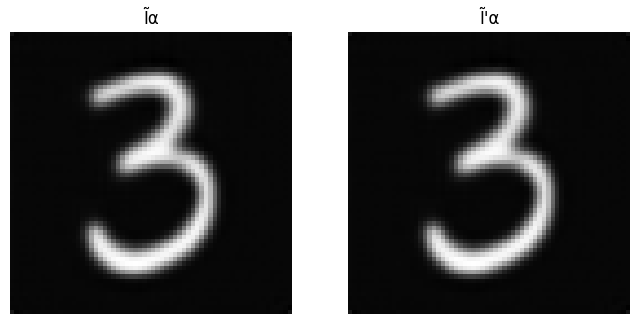

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 4 <--------------------------------



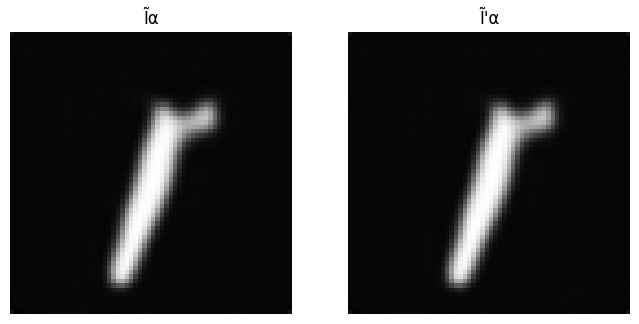

PSNR Value inf ----- L2 value 0.0


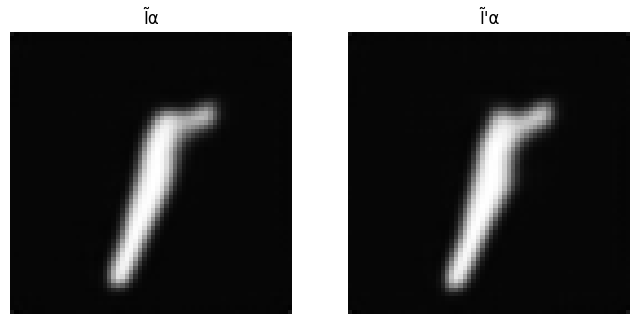

PSNR Value 58.29718017578125 ----- L2 value 2.2322890758514404


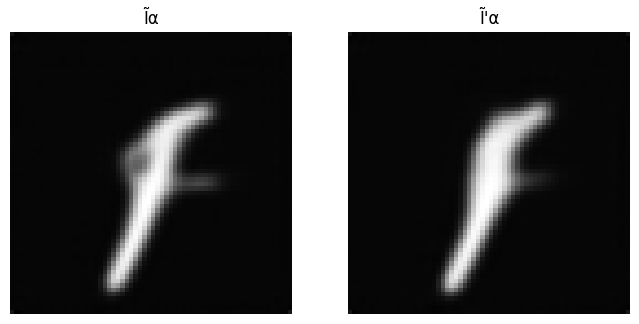

PSNR Value 46.588016510009766 ----- L2 value 4.380054950714111


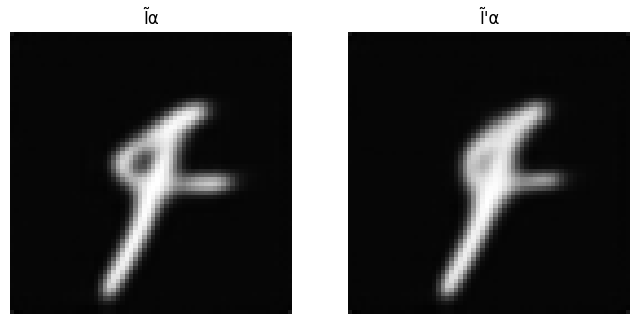

PSNR Value 39.24409484863281 ----- L2 value 6.684633731842041


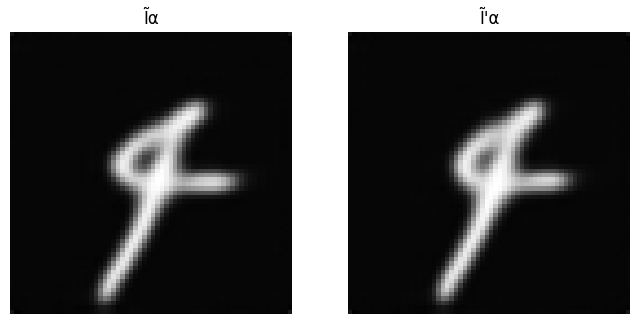

PSNR Value 51.03788375854492 ----- L2 value 3.390259265899658


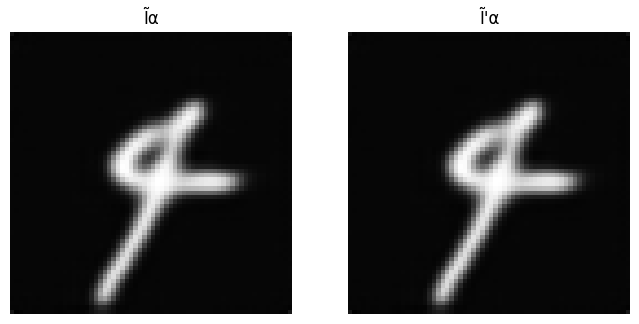

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 5 <--------------------------------



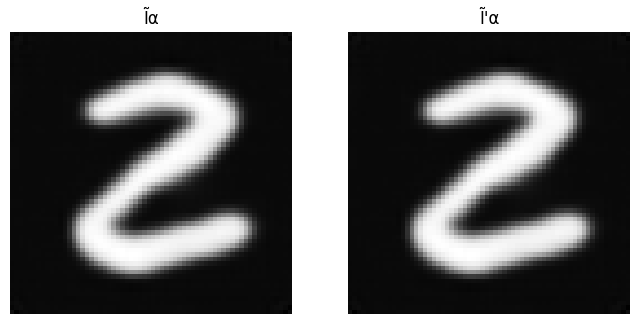

PSNR Value inf ----- L2 value 0.0


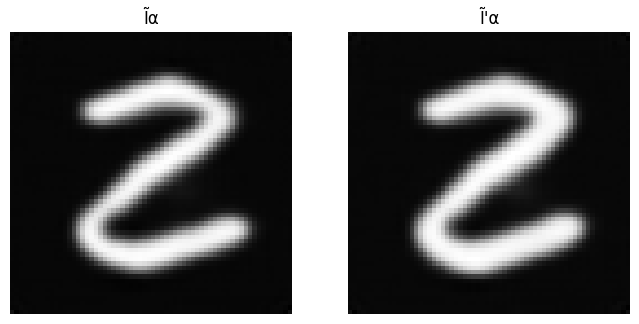

PSNR Value 37.707794189453125 ----- L2 value 7.302727699279785


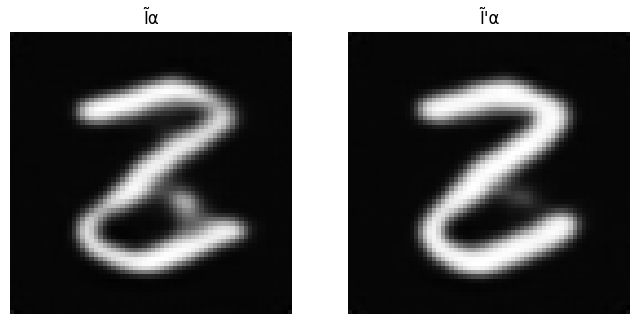

PSNR Value 29.342376708984375 ----- L2 value 11.820083618164062


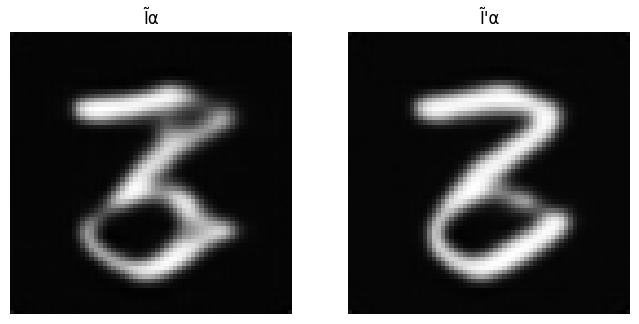

PSNR Value 26.288414001464844 ----- L2 value 14.091903686523438


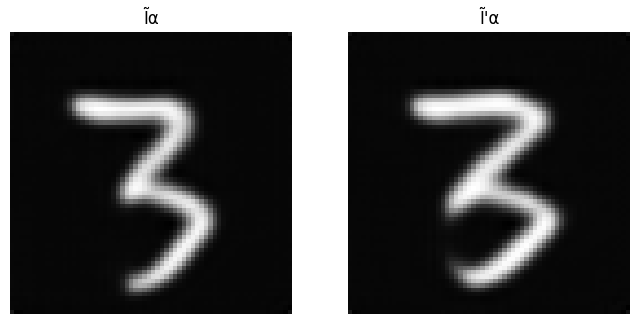

PSNR Value 26.85694694519043 ----- L2 value 13.638176918029785


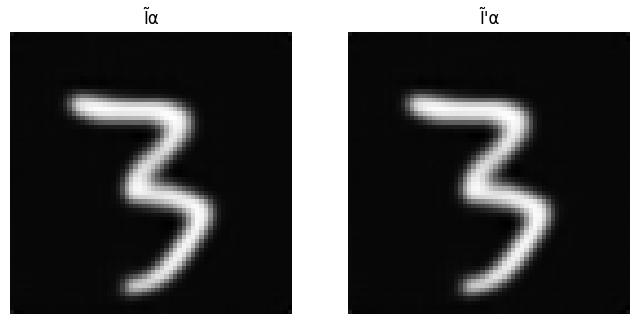

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 6 <--------------------------------



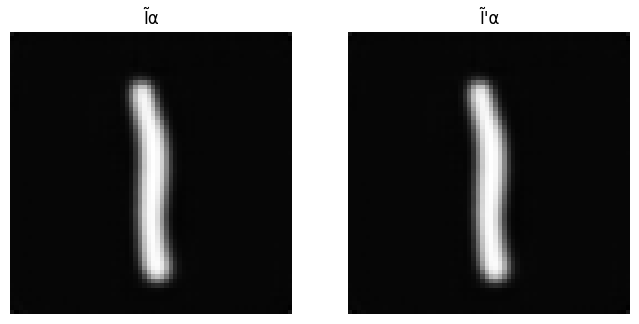

PSNR Value inf ----- L2 value 0.0


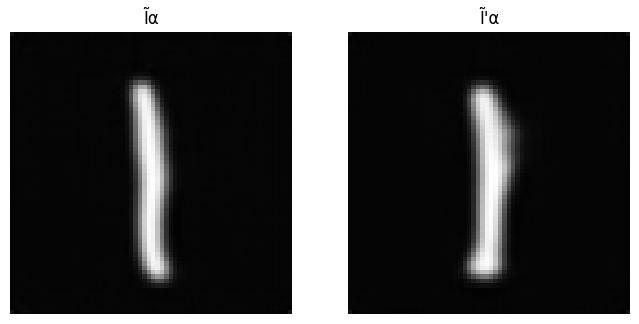

PSNR Value 36.3128547668457 ----- L2 value 7.913318634033203


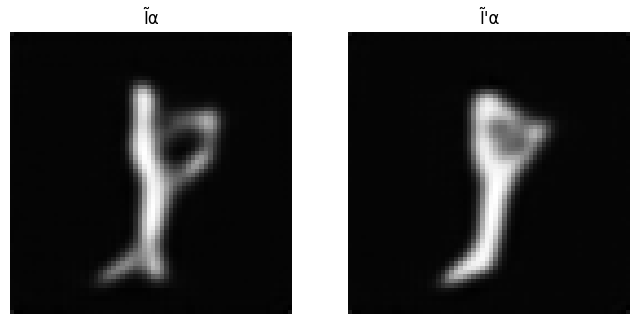

PSNR Value 28.054393768310547 ----- L2 value 12.729756355285645


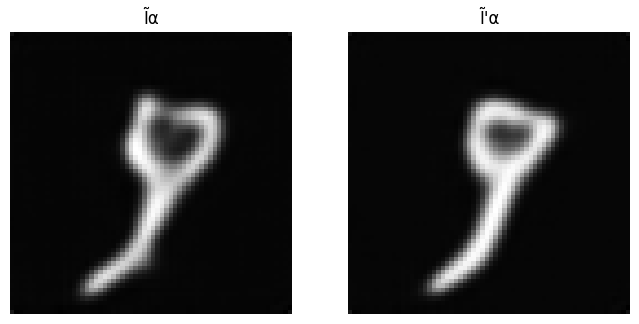

PSNR Value 30.58640480041504 ----- L2 value 11.00322151184082


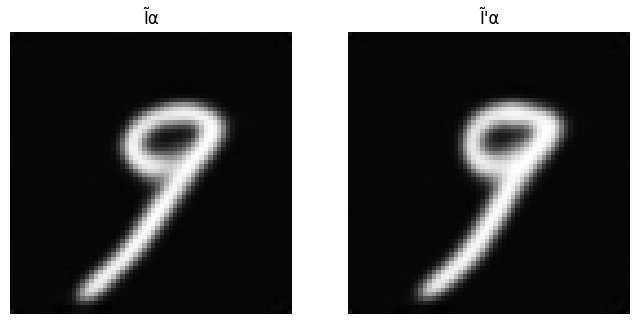

PSNR Value 41.52552795410156 ----- L2 value 5.861946105957031


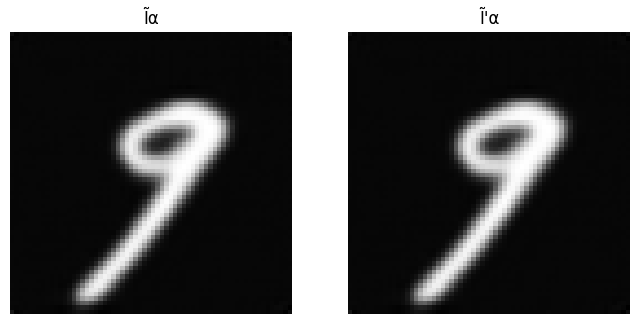

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 7 <--------------------------------



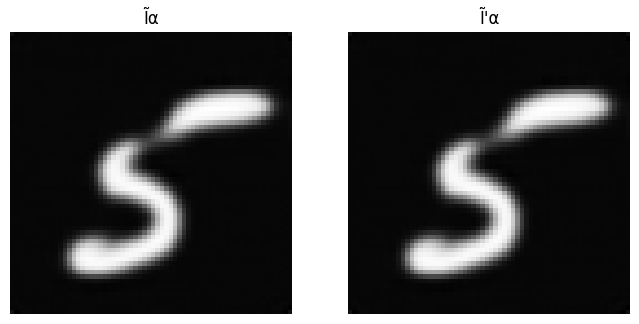

PSNR Value inf ----- L2 value 0.0


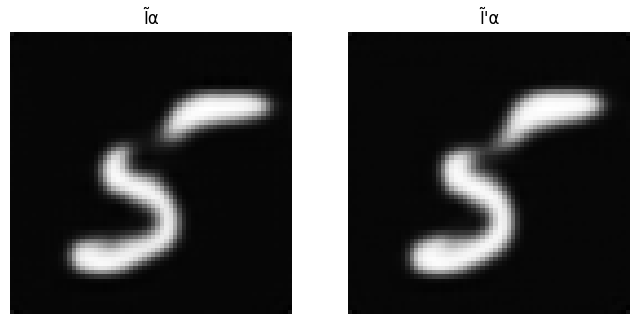

PSNR Value 40.64065933227539 ----- L2 value 6.168272018432617


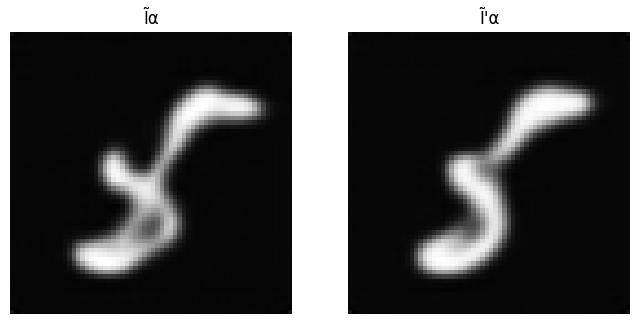

PSNR Value 30.577434539794922 ----- L2 value 11.008903503417969


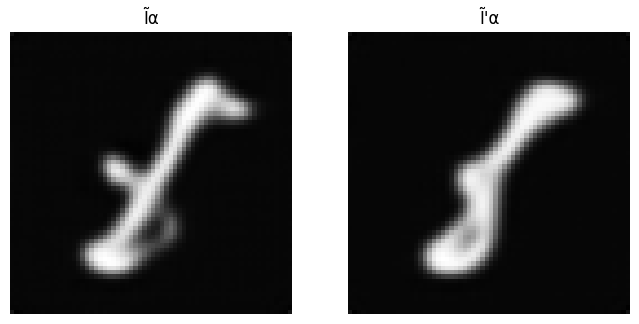

PSNR Value 28.939111709594727 ----- L2 value 12.097681999206543


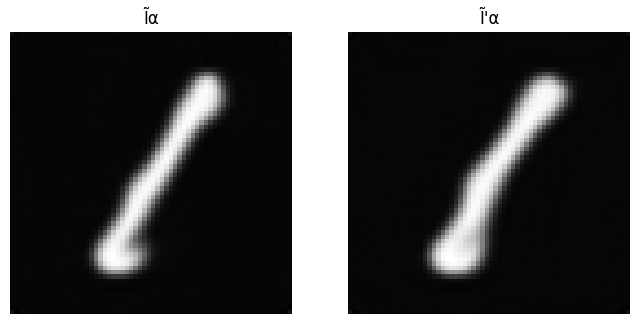

PSNR Value 41.75171661376953 ----- L2 value 5.786114692687988


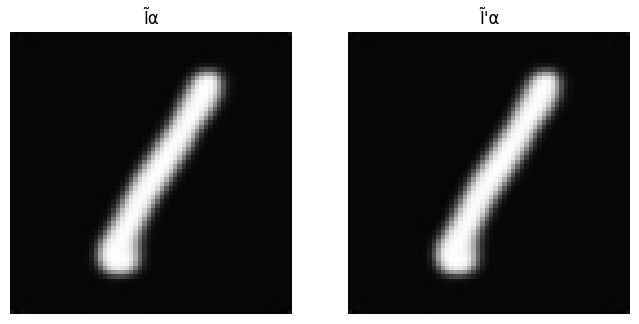

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 8 <--------------------------------



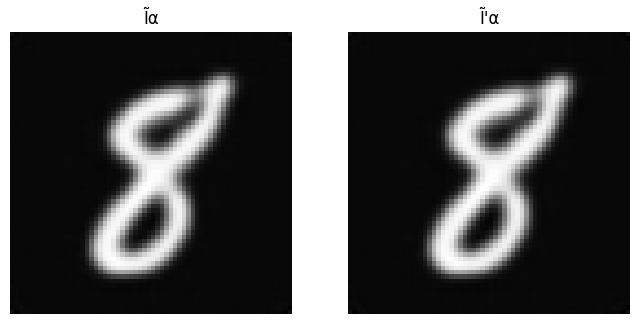

PSNR Value inf ----- L2 value 0.0


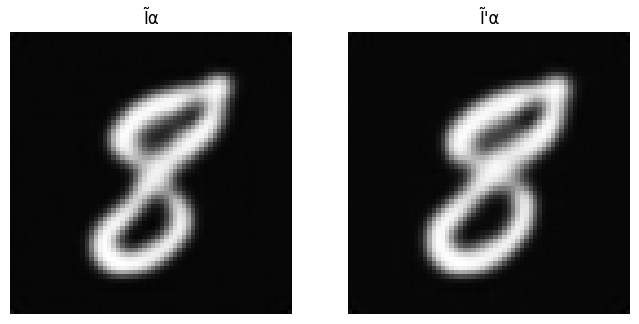

PSNR Value 32.21046829223633 ----- L2 value 10.02116870880127


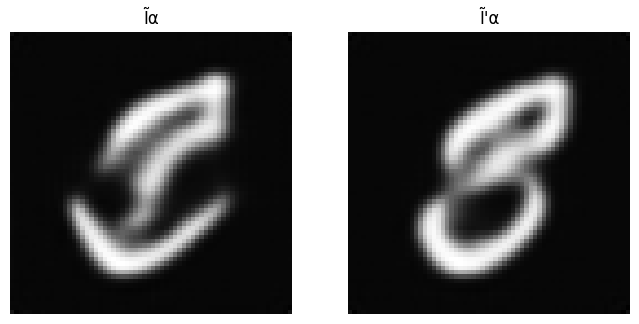

PSNR Value 23.486652374267578 ----- L2 value 16.5582218170166


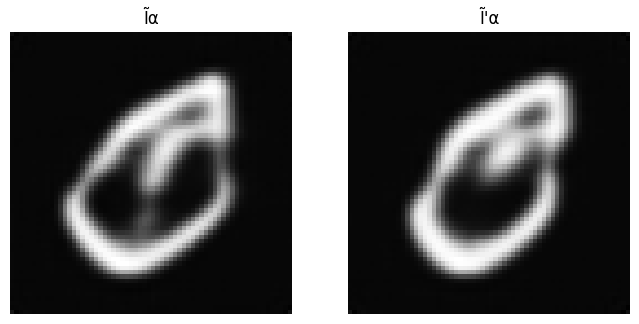

PSNR Value 24.75832748413086 ----- L2 value 15.389405250549316


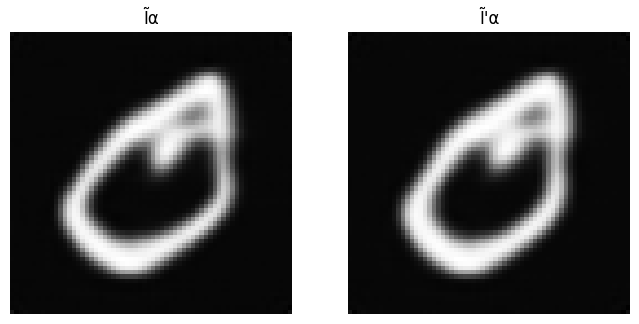

PSNR Value 35.130496978759766 ----- L2 value 8.47066593170166


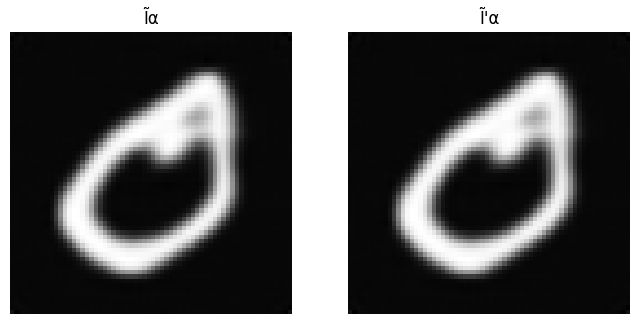

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 9 <--------------------------------



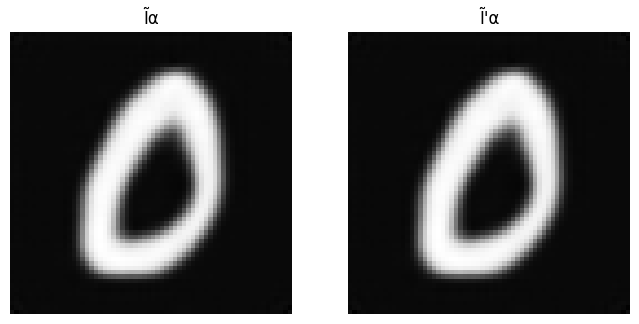

PSNR Value inf ----- L2 value 0.0


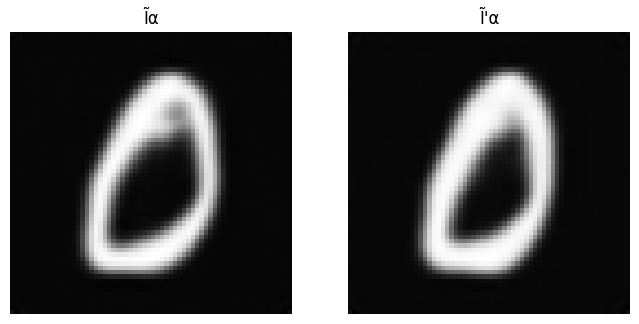

PSNR Value 32.215152740478516 ----- L2 value 10.018464088439941


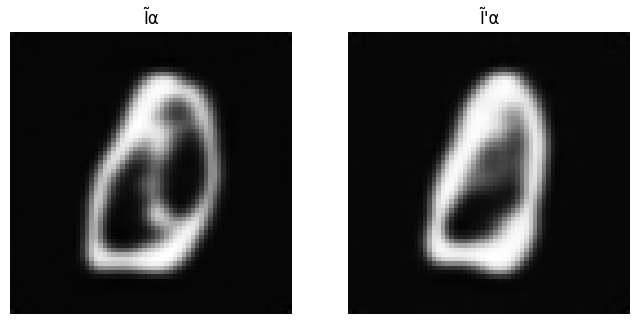

PSNR Value 19.750640869140625 ----- L2 value 20.53118324279785


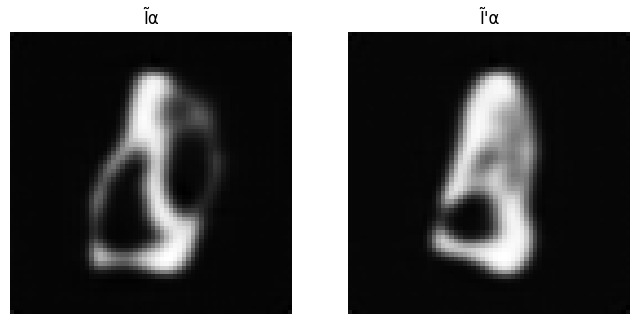

PSNR Value 21.08382225036621 ----- L2 value 19.01447868347168


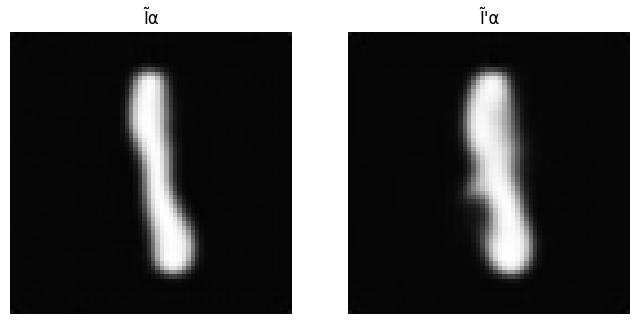

PSNR Value 33.75655746459961 ----- L2 value 9.16781997680664


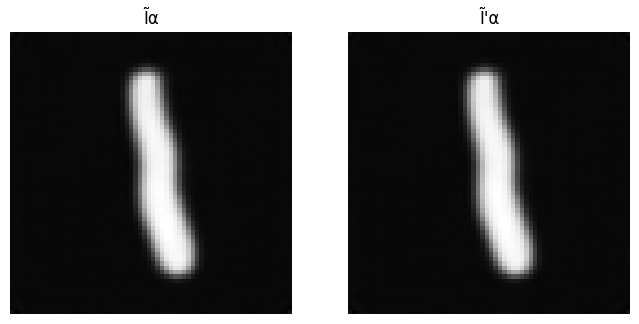

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 10 <--------------------------------



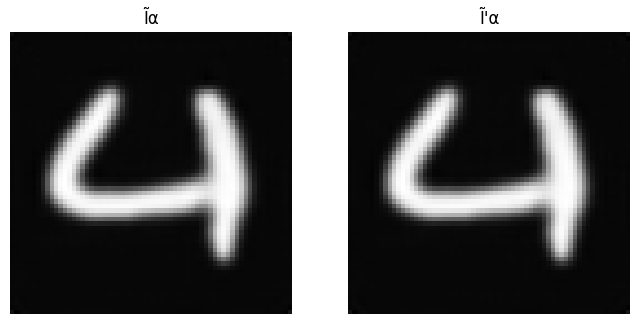

PSNR Value inf ----- L2 value 0.0


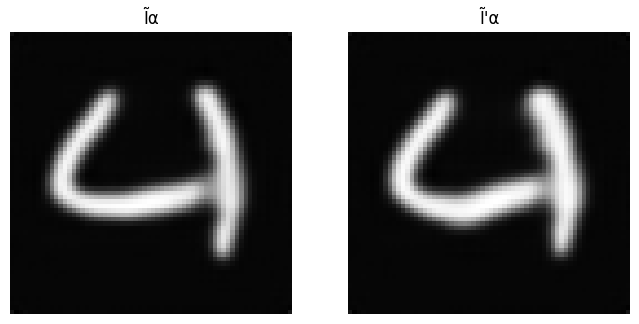

PSNR Value 36.28644943237305 ----- L2 value 7.925355434417725


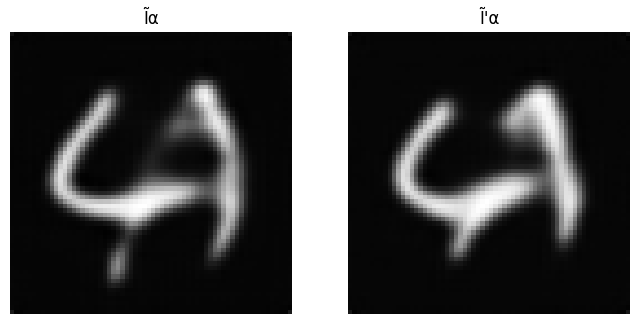

PSNR Value 27.575132369995117 ----- L2 value 13.085843086242676


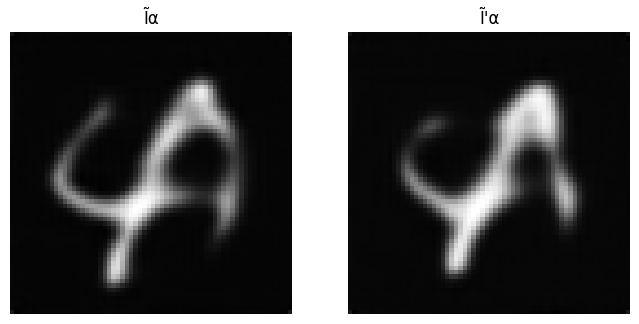

PSNR Value 28.13671875 ----- L2 value 12.669573783874512


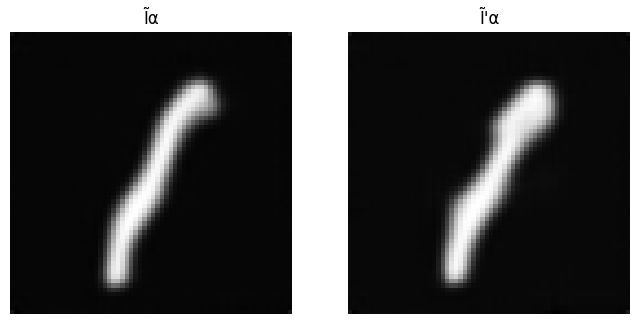

PSNR Value 36.47980499267578 ----- L2 value 7.83763313293457


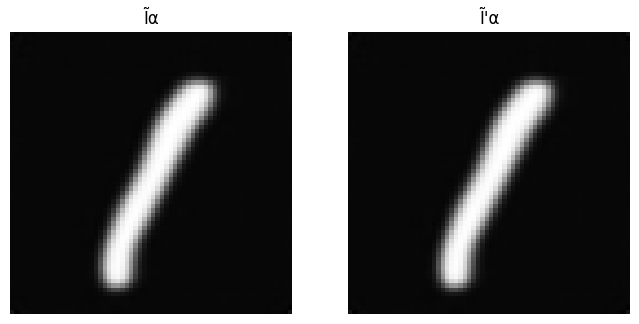

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 11 <--------------------------------



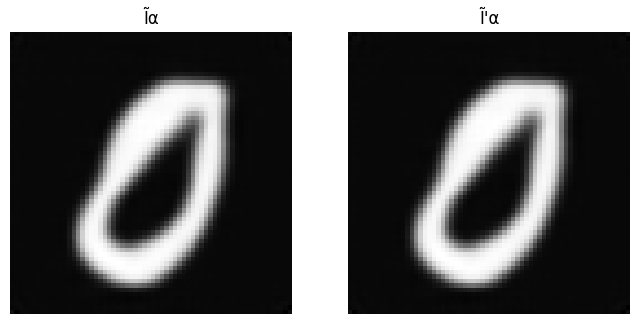

PSNR Value inf ----- L2 value 0.0


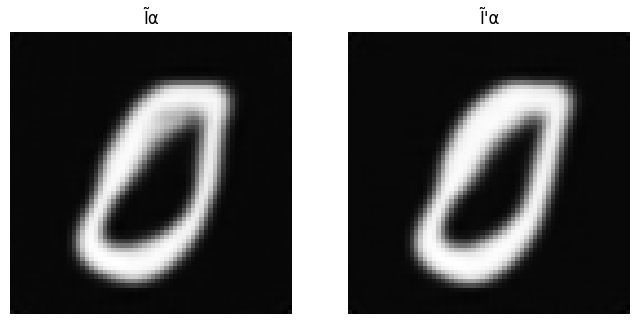

PSNR Value 40.19722366333008 ----- L2 value 6.3277506828308105


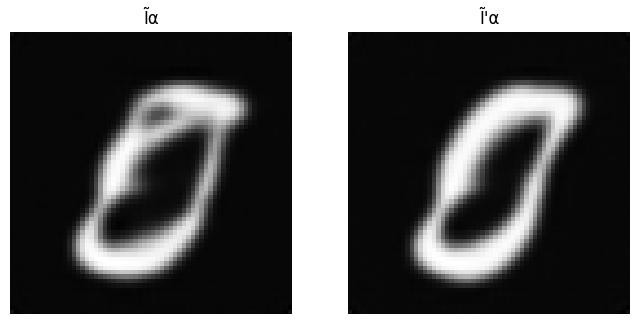

PSNR Value 29.182674407958984 ----- L2 value 11.92924976348877


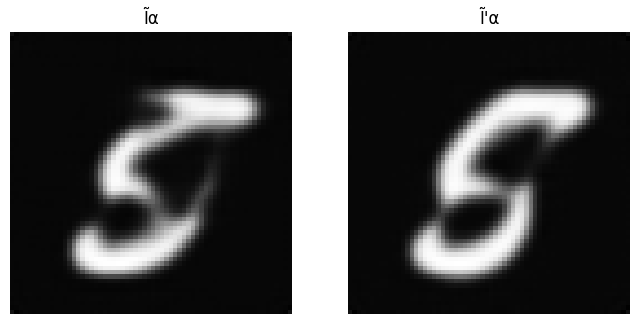

PSNR Value 26.843692779541016 ----- L2 value 13.64858627319336


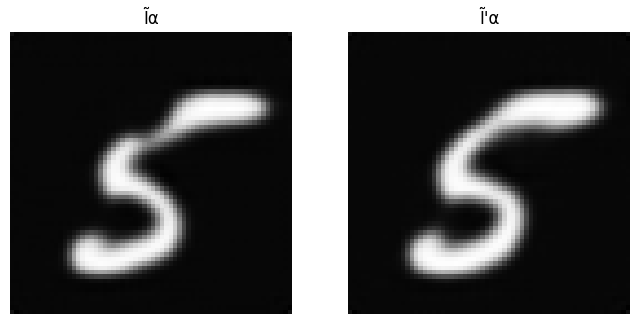

PSNR Value 30.887248992919922 ----- L2 value 10.814310073852539


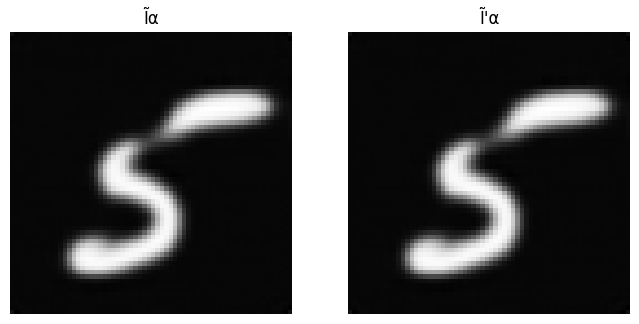

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 12 <--------------------------------



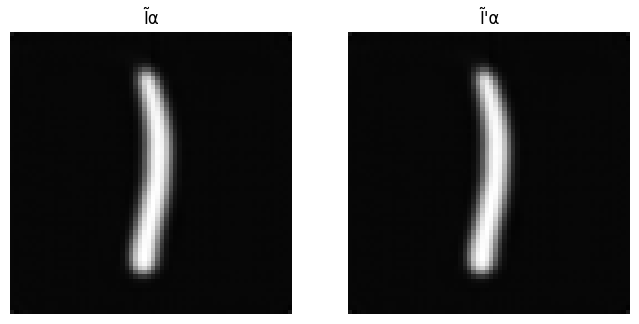

PSNR Value inf ----- L2 value 0.0


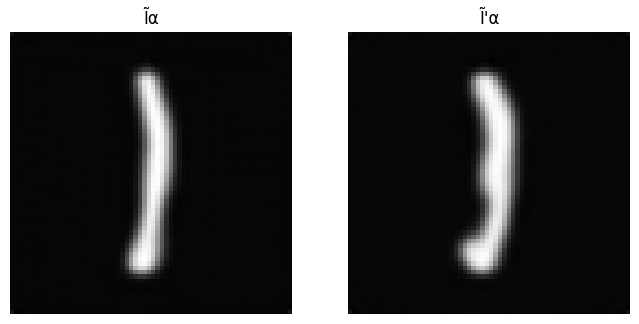

PSNR Value 34.068260192871094 ----- L2 value 9.00478744506836


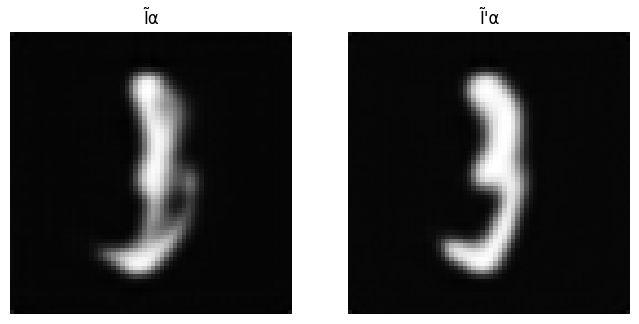

PSNR Value 28.31559181213379 ----- L2 value 12.539787292480469


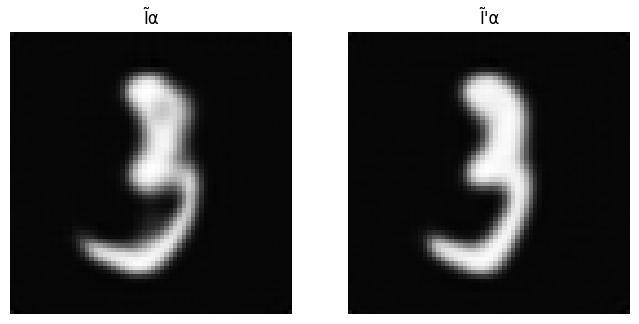

PSNR Value 32.61176300048828 ----- L2 value 9.792327880859375


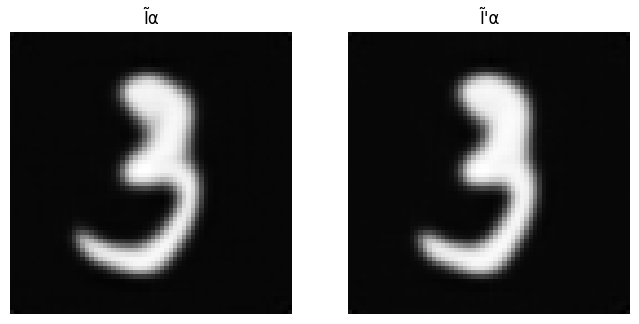

PSNR Value 44.86961364746094 ----- L2 value 4.8354811668396


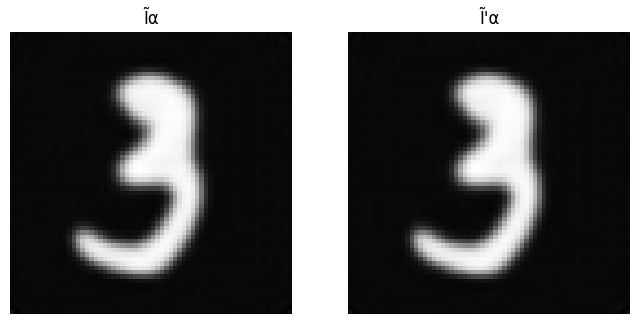

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 13 <--------------------------------



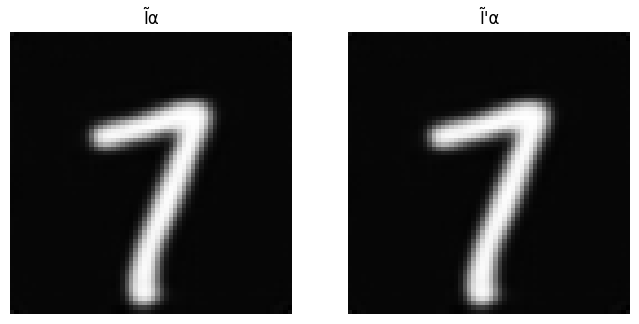

PSNR Value inf ----- L2 value 0.0


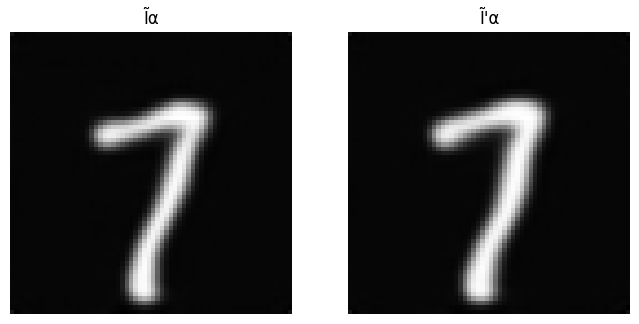

PSNR Value 39.596282958984375 ----- L2 value 6.55047607421875


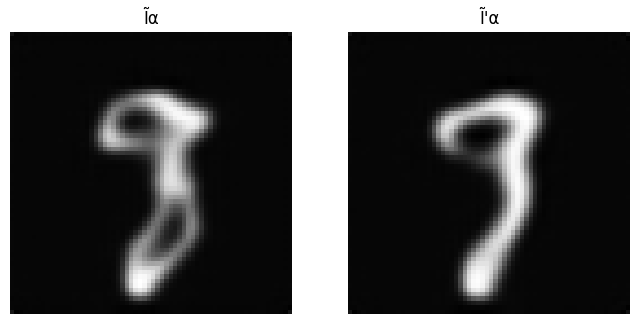

PSNR Value 26.56284523010254 ----- L2 value 13.8710355758667


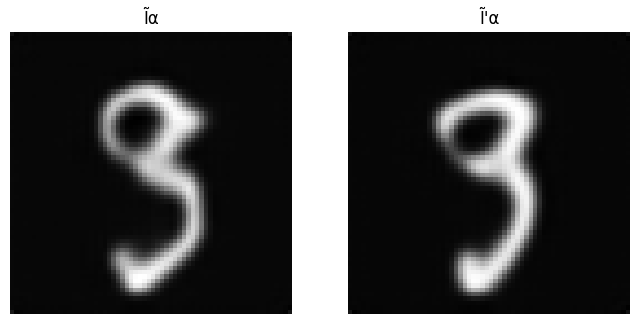

PSNR Value 27.69931411743164 ----- L2 value 12.992632865905762


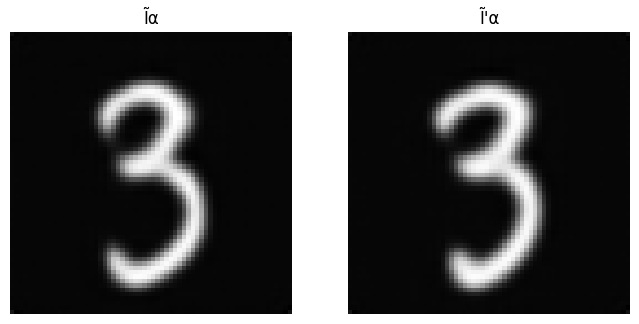

PSNR Value 39.42502975463867 ----- L2 value 6.6153717041015625


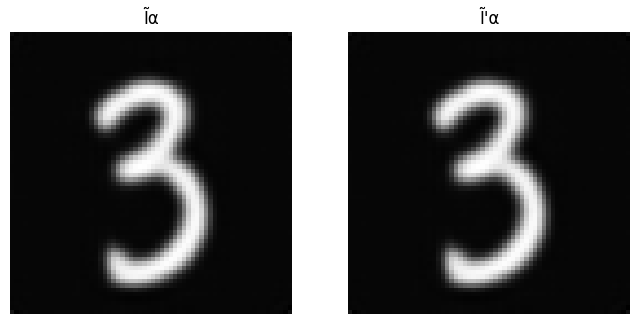

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 14 <--------------------------------



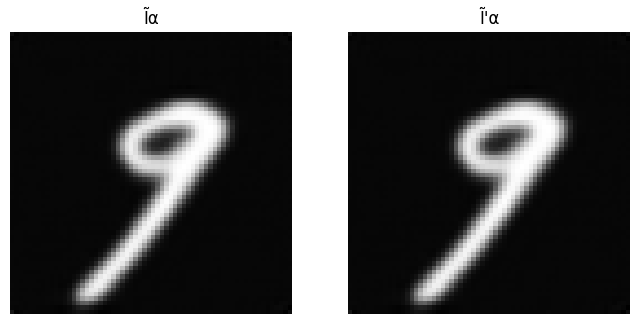

PSNR Value inf ----- L2 value 0.0


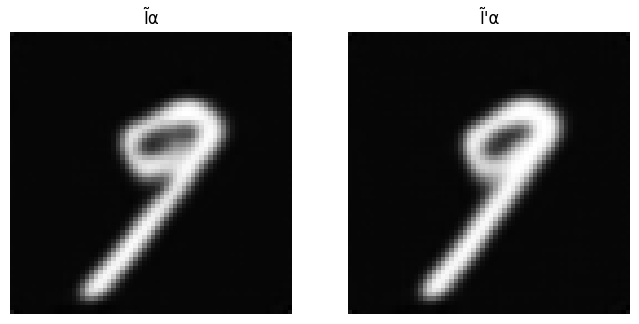

PSNR Value 39.37839889526367 ----- L2 value 6.633152484893799


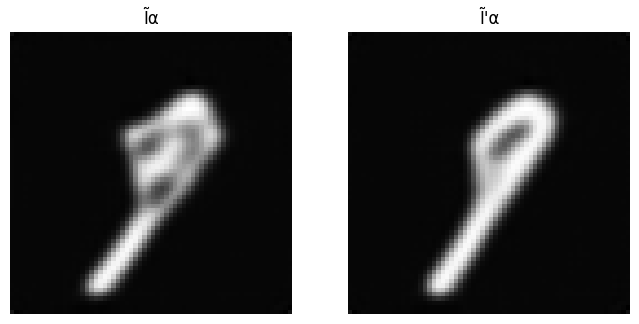

PSNR Value 30.471424102783203 ----- L2 value 11.076292037963867


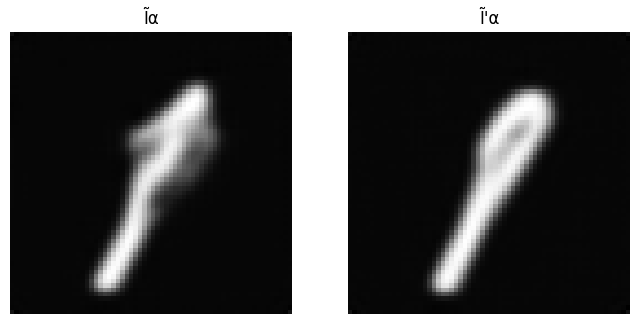

PSNR Value 33.093326568603516 ----- L2 value 9.524601936340332


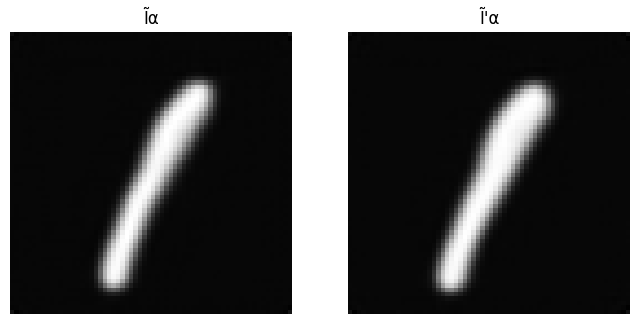

PSNR Value 45.61046600341797 ----- L2 value 4.6335978507995605


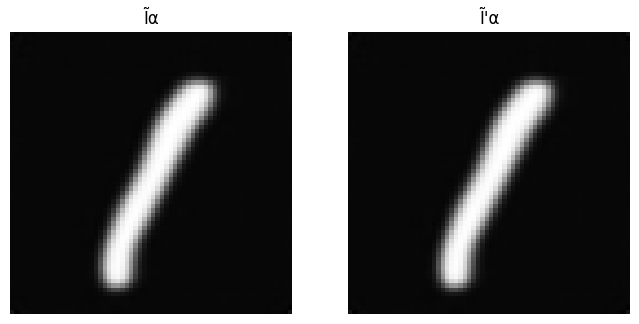

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 15 <--------------------------------



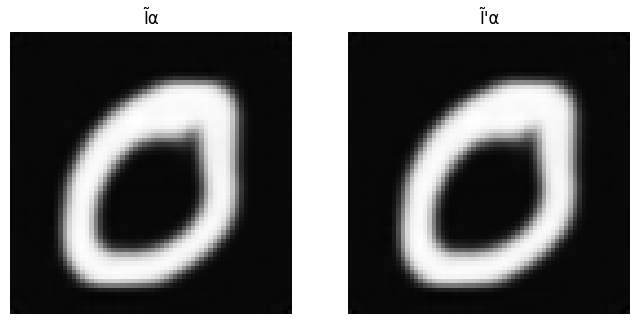

PSNR Value inf ----- L2 value 0.0


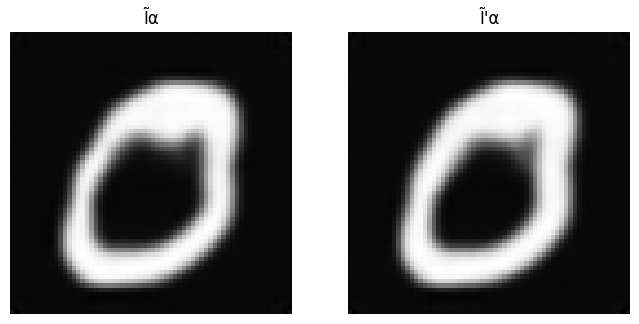

PSNR Value 36.75106430053711 ----- L2 value 7.716198921203613


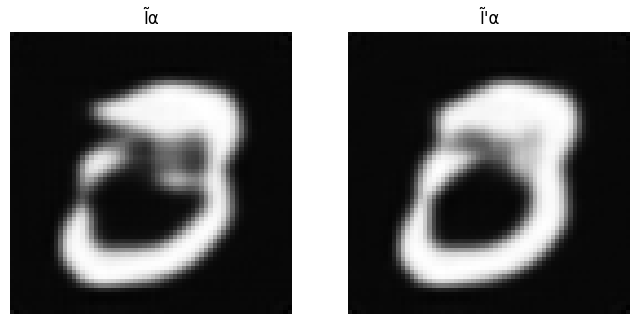

PSNR Value 27.05662727355957 ----- L2 value 13.48231029510498


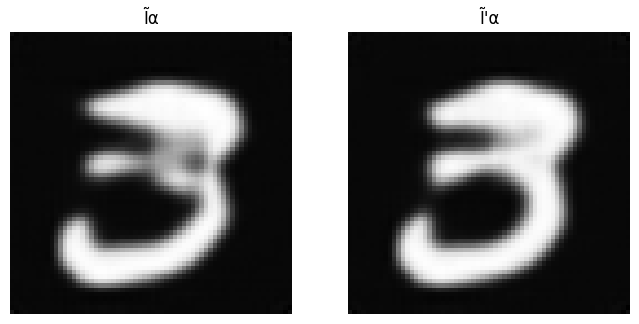

PSNR Value 29.631376266479492 ----- L2 value 11.625069618225098


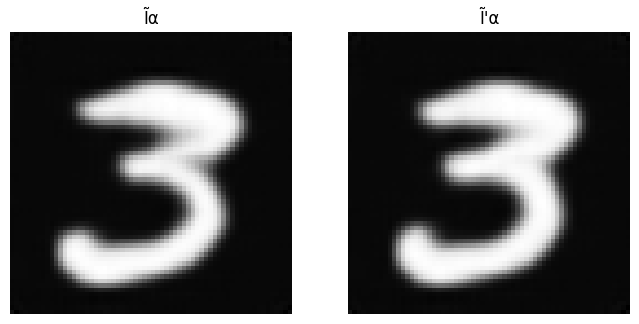

PSNR Value 37.230838775634766 ----- L2 value 7.506007671356201


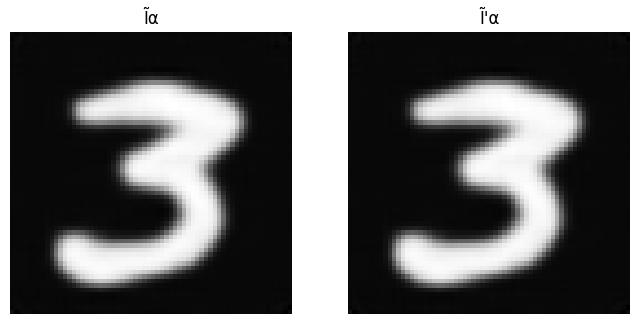

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 16 <--------------------------------



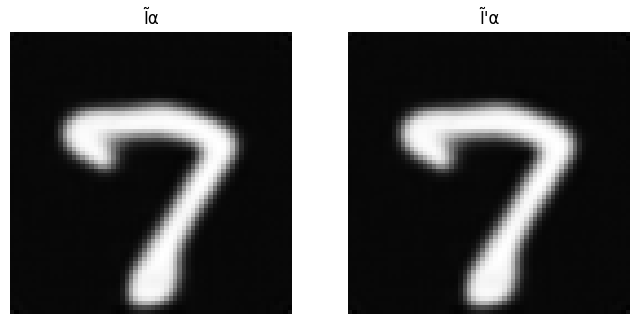

PSNR Value inf ----- L2 value 0.0


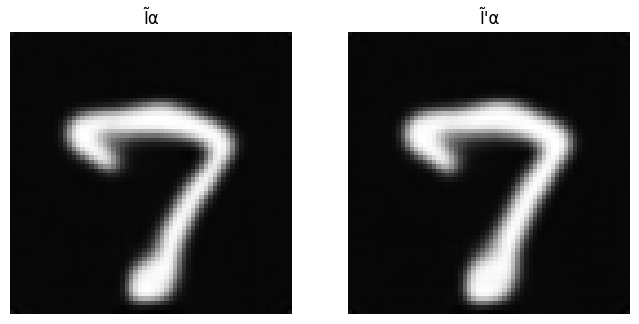

PSNR Value 42.30242156982422 ----- L2 value 5.605565547943115


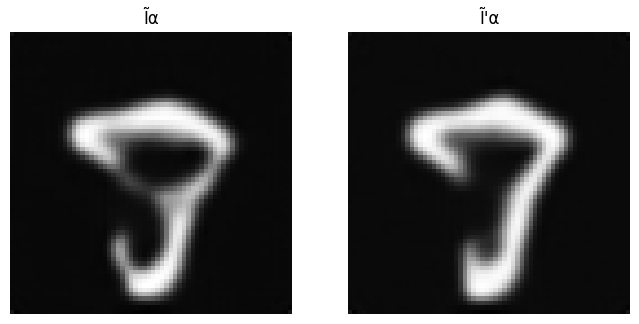

PSNR Value 31.749797821044922 ----- L2 value 10.29046630859375


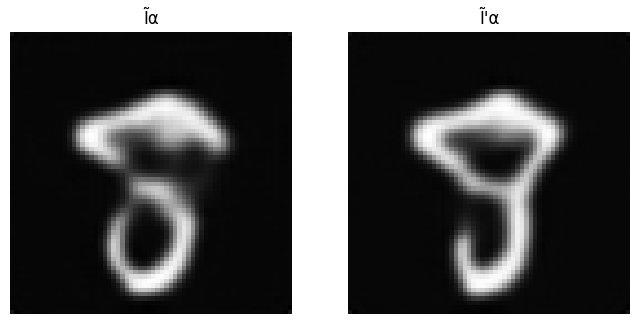

PSNR Value 28.16779327392578 ----- L2 value 12.646929740905762


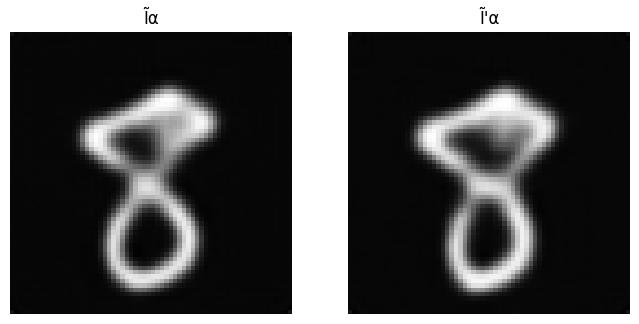

PSNR Value 33.44342803955078 ----- L2 value 9.334569931030273


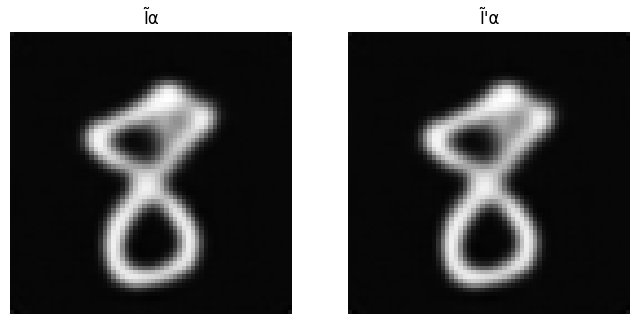

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 17 <--------------------------------



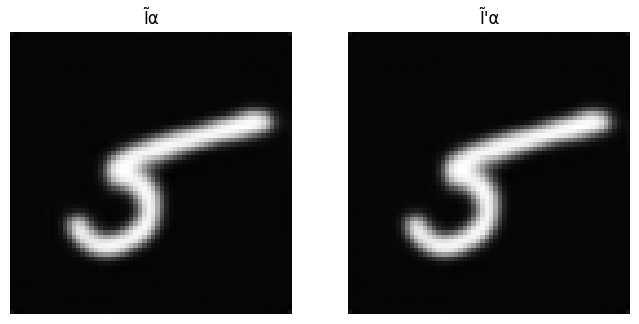

PSNR Value inf ----- L2 value 0.0


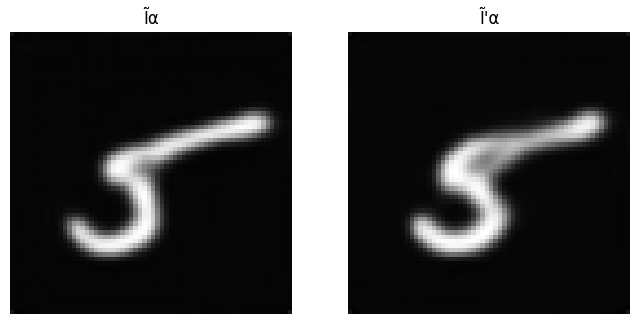

PSNR Value 32.74686813354492 ----- L2 value 9.71646499633789


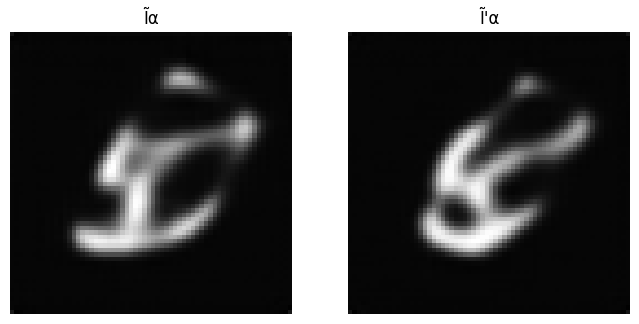

PSNR Value 25.207996368408203 ----- L2 value 14.996160507202148


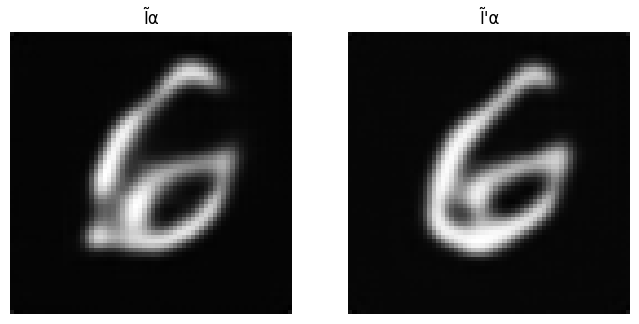

PSNR Value 27.11029815673828 ----- L2 value 13.44072151184082


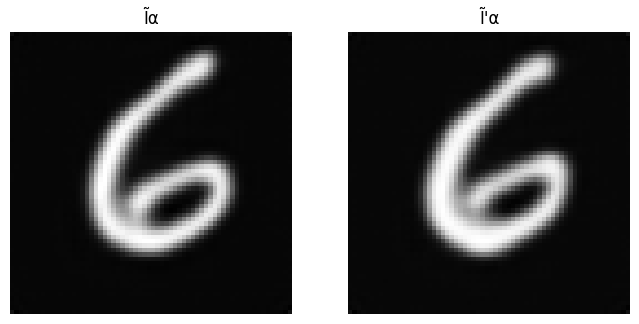

PSNR Value 35.01324462890625 ----- L2 value 8.528032302856445


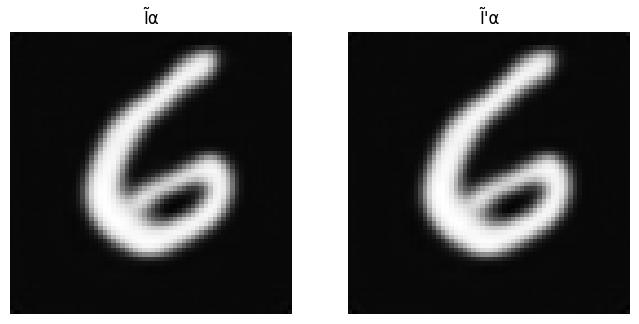

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 18 <--------------------------------



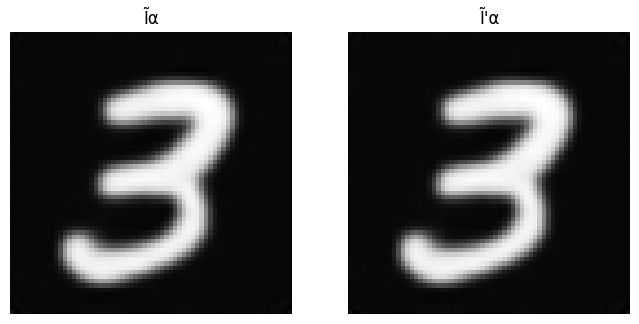

PSNR Value inf ----- L2 value 0.0


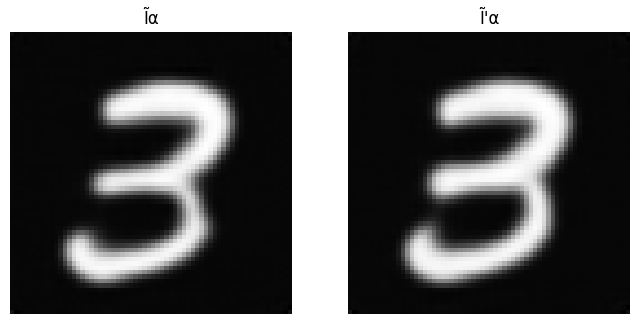

PSNR Value 33.098453521728516 ----- L2 value 9.521791458129883


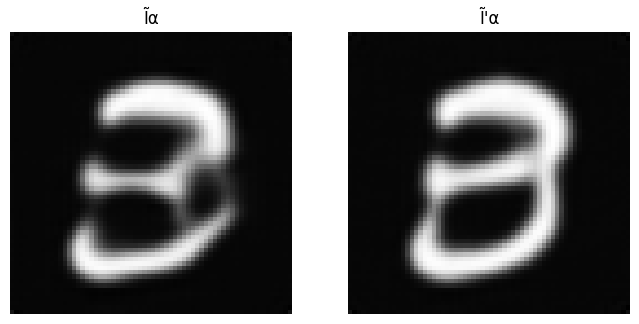

PSNR Value 23.856809616088867 ----- L2 value 16.209131240844727


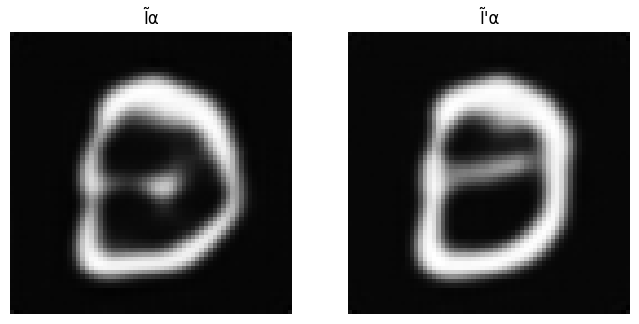

PSNR Value 23.055822372436523 ----- L2 value 16.974008560180664


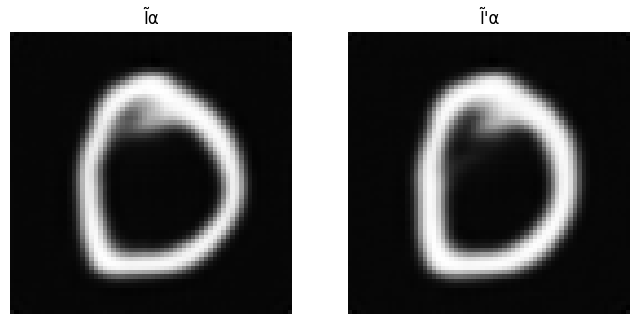

PSNR Value 33.17473602294922 ----- L2 value 9.480072021484375


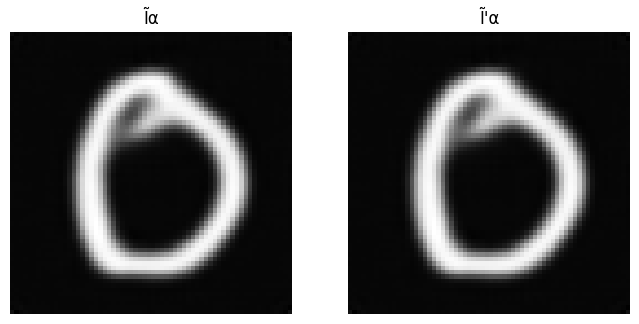

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 19 <--------------------------------



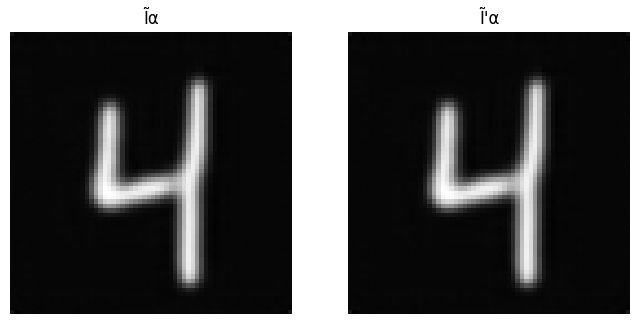

PSNR Value inf ----- L2 value 0.0


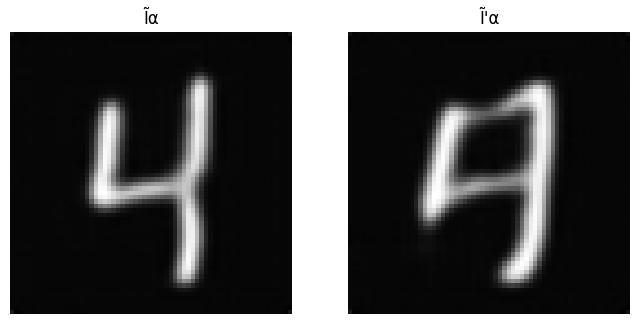

PSNR Value 24.276464462280273 ----- L2 value 15.82225513458252


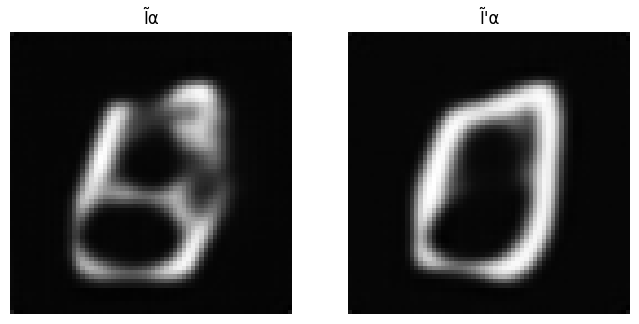

PSNR Value 21.226436614990234 ----- L2 value 18.859018325805664


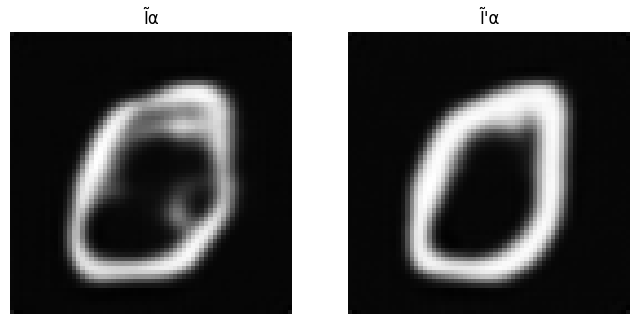

PSNR Value 23.361608505249023 ----- L2 value 16.677839279174805


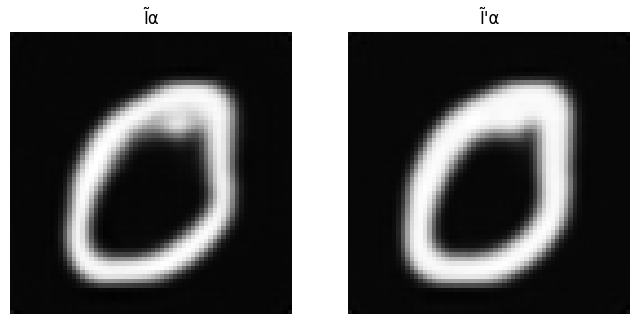

PSNR Value 33.408668518066406 ----- L2 value 9.353266716003418


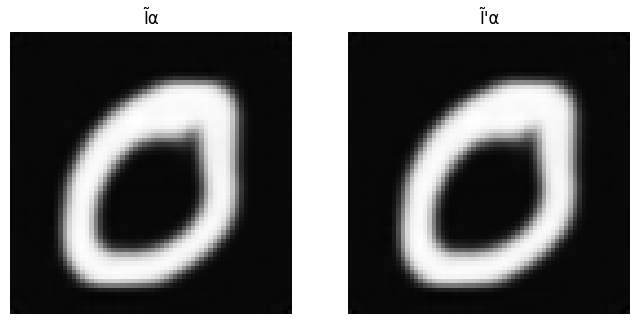

PSNR Value inf ----- L2 value 0.0

--------------------------------> For the image Pair 20 <--------------------------------



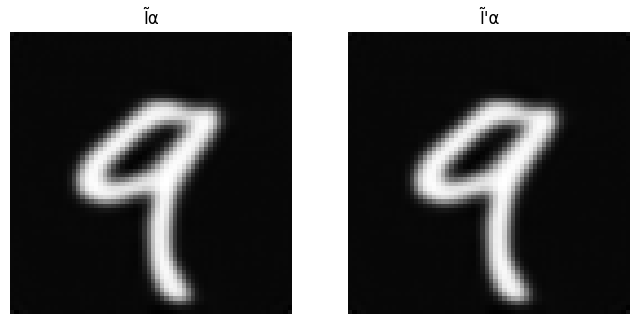

PSNR Value inf ----- L2 value 0.0


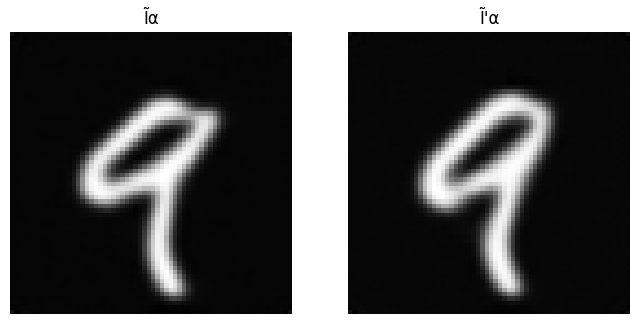

PSNR Value 35.379669189453125 ----- L2 value 8.350034713745117


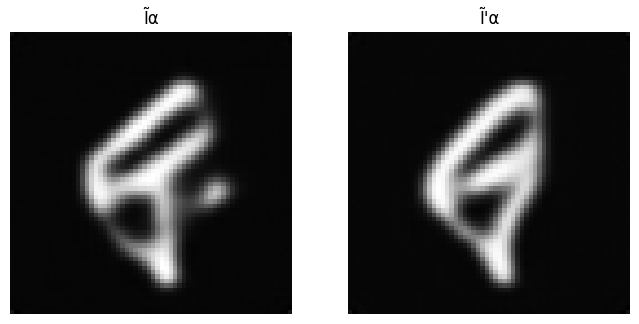

PSNR Value 25.505054473876953 ----- L2 value 14.74190616607666


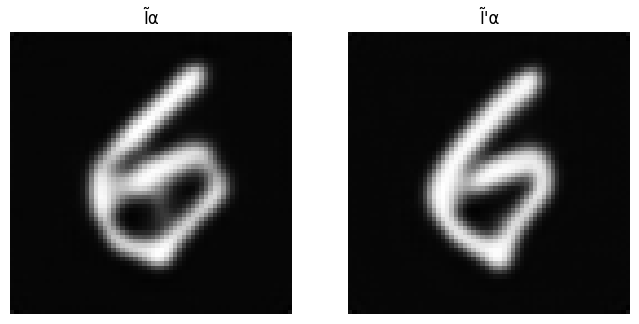

PSNR Value 27.197444915771484 ----- L2 value 13.37346363067627


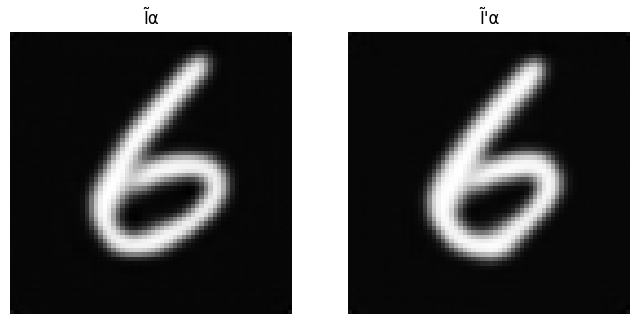

PSNR Value 37.42343521118164 ----- L2 value 7.423250198364258


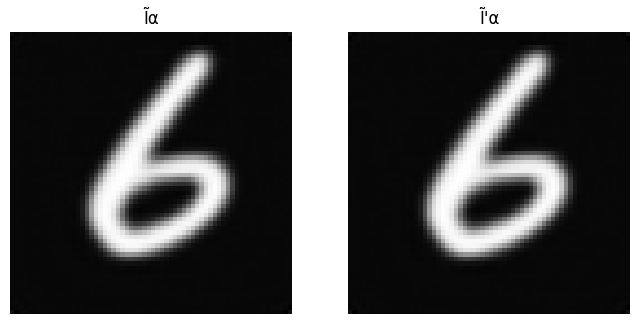

PSNR Value inf ----- L2 value 0.0


In [33]:
alphas=[0, 0.2, 0.4, 0.6, 0.8, 1.]
for i in range(1,21):
    for featues, labels in data_loader_q2:
        if labels[0]!=labels[1]:
            break
        else:
            pass
    print(f'\n--------------------------------> For the image Pair {i} <--------------------------------\n')
    for alpha in alphas:
        I1=featues[0]
        I2=featues[1]
        I1=I1.to(device)
        I2=I2.to(device)

        I_alpha=alpha*I1+(1-alpha)*I2

        model.eval()
        with torch.no_grad():
            # encoder Embeddings
            h_alpha=model.encoder(I_alpha)
            h1=model.encoder(I1)
            h2=model.encoder(I2)

            h_dash_alpha=alpha*h1+(1-alpha)*h2

            h_alpha_bottle_neck=model.bottleneck(h_alpha)
            h_dash_alpha_bottle_neck=model.bottleneck(h_dash_alpha)

            i_alpha_hat=model.decoder(h_alpha_bottle_neck)
            i_dash_alpha_hat=model.decoder(h_dash_alpha_bottle_neck)

            psnr=calculate_psnr(i_alpha_hat,i_dash_alpha_hat)
            l2=l2norm(i_alpha_hat,i_dash_alpha_hat)

            # Prepare for plotting
            i_alpha_hat_img = i_alpha_hat.squeeze().cpu().numpy()
            i_dash_alpha__img = i_dash_alpha_hat.squeeze().cpu().numpy()

            # De-normalize if needed (from [-1,1] back to [0,1])
            i_alpha_hat_img = (i_alpha_hat_img * 0.5) + 0.5
            i_dash_alpha__img = (i_dash_alpha__img * 0.5) + 0.5

            # Plot side by side
            plt.figure(figsize=(8,4))

            # Input
            plt.subplot(1,2,1)
            plt.imshow(i_alpha_hat_img, cmap='gray')
            plt.title("Ĩα")
            plt.axis('off')

            # Output
            plt.subplot(1,2,2)
            plt.imshow(i_dash_alpha__img, cmap='gray')
            plt.title("Ĩ'α")
            plt.axis('off')

            plt.show()
            print(f'PSNR Value {psnr} ----- L2 value {l2}')

![image.png](attachment:image.png)

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

subset_indices=list(range(3000))
subset_data_set=Subset(train_dataset,subset_indices)
data_loader_q3 = DataLoader(subset_data_set,batch_size=100,shuffle=True)

In [36]:
sample_features=[]
labels=[]
for featues, label in data_loader_q3:
  featues=featues.to(device)
  model.eval()
  with torch.no_grad():
          # encoder Embeddings
          embedded=model.encoder(featues)
          embedded_flat=embedded.view(embedded.size(0),-1)
          sample_features.append(embedded_flat)
          labels.append(label)
sample_features=torch.cat(sample_features,dim=0)
labels=torch.cat(labels,dim=0)

X_train,X_test,y_train,y_test=train_test_split(sample_features,labels,test_size=0.2,random_state=42)

In [37]:
print(f'Sample Features shape: {sample_features.shape}')
print(f'labels Shape {labels.shape}')

Sample Features shape: torch.Size([3000, 32768])
labels Shape torch.Size([3000])


In [38]:
y_train

tensor([9, 6, 6,  ..., 9, 9, 2])

In [42]:
#Model Definition
log_reg_model=LogisticRegression(max_iter=1000)

#Fit the model
log_reg_model.fit(X_train.cpu(),y_train.cpu())

LogisticRegression(max_iter=1000)

In [45]:
#Predict
y_pred=log_reg_model.predict(X_test.cpu())

#Evaluate
acc=accuracy_score(y_test,y_pred)

print(f'Accuracy of Classification using Sparse Auto Encoder is: {acc}')

Accuracy of Classification using Sparse Auto Encoder is: 0.9483333333333334
